In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
digits = datasets.load_digits()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
print("Dataset Keys:")
print(digits.keys())

Dataset Keys:
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [7]:
print("Image Shape:", digits.images.shape)
print("Data Shape:", digits.data.shape)
print("Target Shape:", digits.target.shape)

Image Shape: (1797, 8, 8)
Data Shape: (1797, 64)
Target Shape: (1797,)


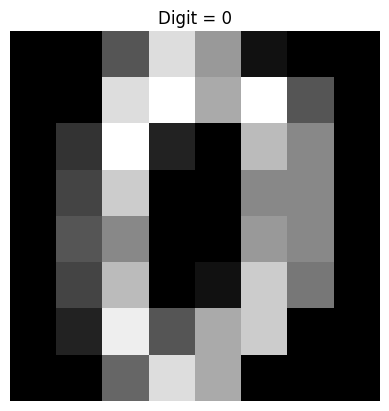

In [9]:
plt.imshow(digits.images[0], cmap='gray')
plt.title("Digit = {}".format(digits.target[0]))
plt.axis("off")
plt.show()

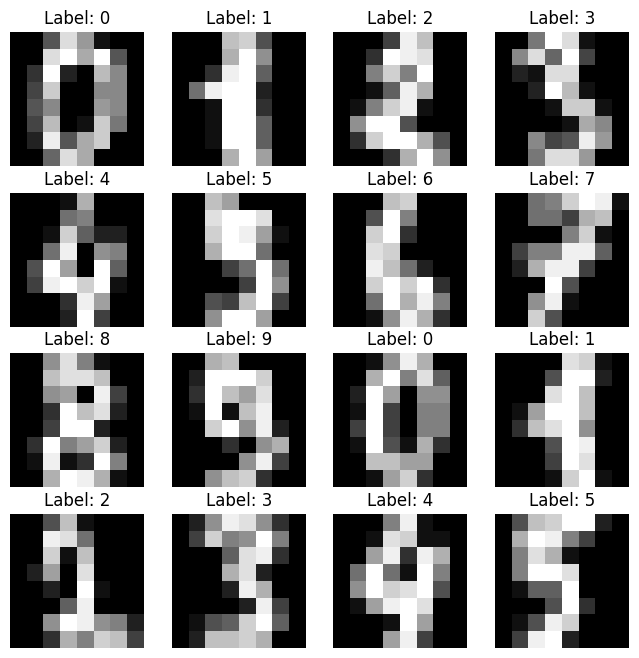

In [11]:
fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title("Label: {}".format(digits.target[i]))
    ax.axis("off")

plt.show()

In [13]:
X = digits.data
y = digits.target

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (1797, 64)
Output Shape: (1797,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (1437, 64)
Testing Samples: (360, 64)


In [17]:
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [19]:
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [21]:
predictions = model.predict(X_test)

print(predictions[:20])

[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]


In [23]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9833333333333333


In [25]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.98      1.00      0.99        46
           5       0.96      0.98      0.97        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.98      1.00      0.99        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [27]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  1  0  0 28  0]
 [ 0  0  0  0  0  0  0  0  0 40]]


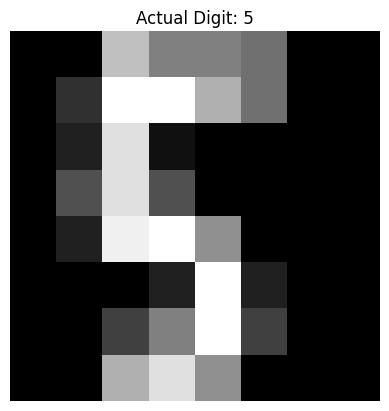

Predicted Digit: 5


In [29]:
index = 25

plt.imshow(digits.images[index], cmap='gray')
plt.title("Actual Digit: {}".format(digits.target[index]))
plt.axis("off")
plt.show()

prediction = model.predict([digits.data[index]])

print("Predicted Digit:", prediction[0])

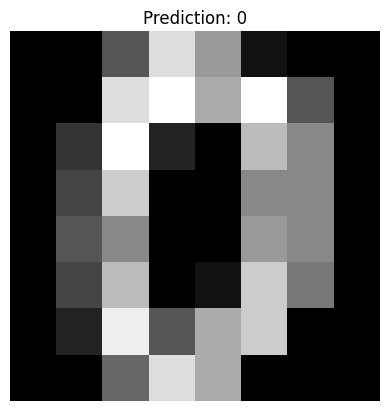

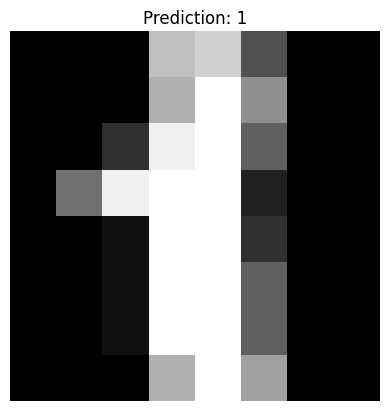

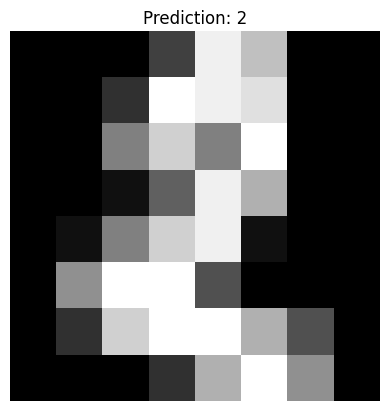

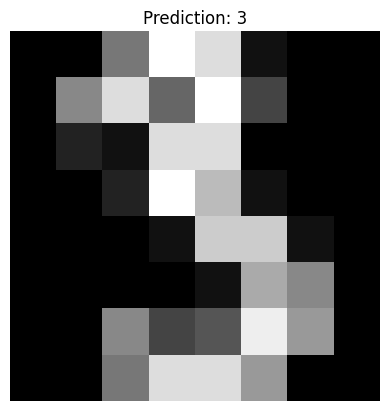

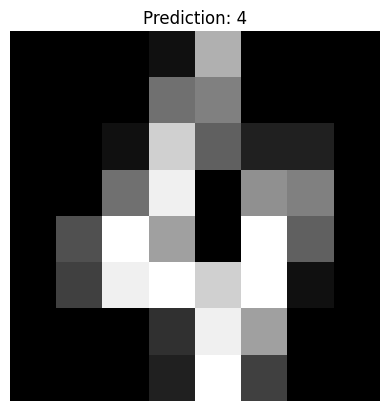

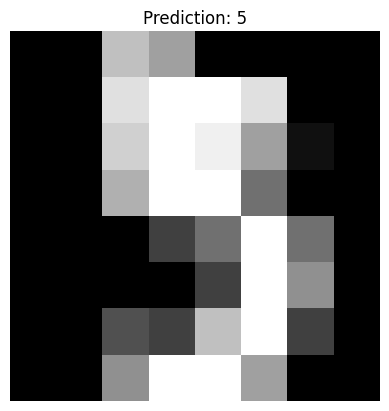

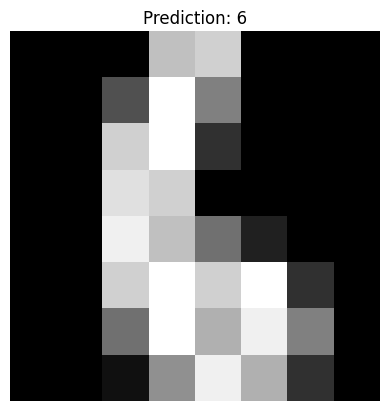

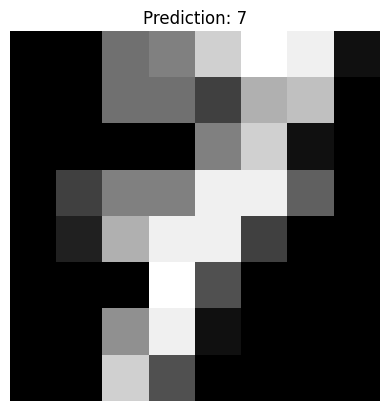

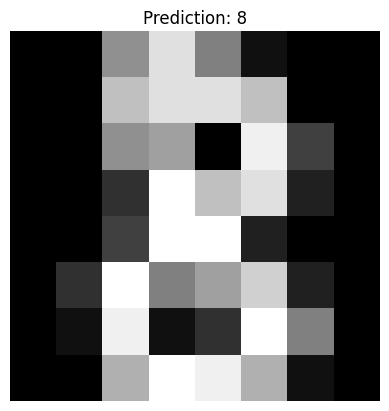

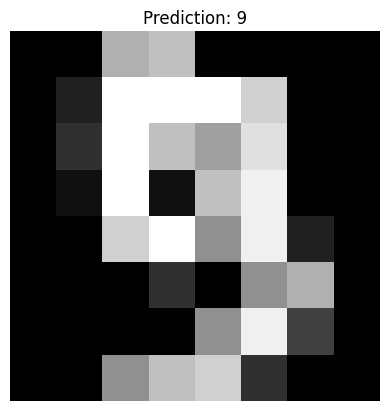

In [31]:
for i in range(10):
    plt.imshow(digits.images[i], cmap='gray')
    plt.title("Prediction: {}".format(model.predict([digits.data[i]])[0]))
    plt.axis("off")
    plt.show()

In [33]:
print("Final Model Accuracy: {:.2f}%".format(accuracy*100))

Final Model Accuracy: 98.33%
